# MCMC Global Fitting Tutorial

This procedure is very similar to the global fits with minimize and it accomplishes the same thing, but using MCMC. MCMC runs using `@jit`-optimized functions in `instruments_jax.py`. 

# Step 1: Move Your Custom Mueller Matrix Functions to `custom_mms`

When using multiprocessing, emcee cannot pickle the user defined functions when they are defined in a notebook like we did earlier. To allow for multiprocessing, you must move your functions to the `custom_mms/custom_mms.py` script and register them there. The `__init__.py` file for pyPolCal will automatically register all of them. All the custom mms from this tutorial are there. 

# Step 2: Read in Data and Prepare Model as in Last Notebook

In [1]:
from pyPolCal.csv_tools import read_csv_physical_model_all_bins
from importlib.resources import files

# Defining Path to my CSVs

csvdir = files('pyPolCal.CHARIS.datacsvs').joinpath('nbs_in_internalcal_csvs')

# Reading in data
interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir)

/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pyPolCal.utils import generate_system_mueller_matrix

system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "fitted_wollaston_function_12_28_2025",
        "properties" : {"beam": 'o'}, 
        "tag": "internal",
        },

        "nbs_rot": {
            "type": "rotator_function",
            "properties": {"pa": 90},
            "tag": "internal",
        },
        "image_rotator" : {
        "type" : "fitted_derotator_function_12_28_2025",
        "properties" : {"delta_theta":0}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"delta_theta": 0},
            "tag": "internal",
        },


        "lp" :{
            "type" : "diattenuator_retarder_function",
            "properties" : {"epsilon": -1, "delta_theta":0}, 
            "tag": "internal",
        },
}
}
system_mm = generate_system_mueller_matrix(system_dict)
system_mm.evaluate()

array([[ 0.99959322, -0.99959322,  0.        ,  0.        ],
       [ 0.99959322, -0.99959322,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

# Step 2: Define Starting Guesses, Bounds, and Priors

The starting guesses procedure is identical to the last notebook, but now you will create a `prior_dict` defining what prior you want to use. You can use either `'uniform'` or `'gaussian'` priors. You can see the format for inputting arguments below. I'm using both prior types so you can see how both arguments work. You will also need to create a `bounds_dict` which you can use to assign bounds to components and parameters.

In [3]:

# Define starting guesses
wsio2 = 1.636
wmgf2 = 1.28

p0_dict = {
    "image_rotator" : 
        {"delta_theta": 0},
    "hwp" :  
        {"w_SiO2": wsio2, "w_MgF2": wmgf2,"delta_theta": 0},
    "lp" : 
        {"delta_theta": 0}
}

# Define bounds
offset_bounds = (-5,5)
wsio2_bounds = (0.5*wsio2, 1.5*wsio2)
wmgf2_bounds = (0.5*wmgf2, 1.5*wmgf2)

bounds_dict = {
    "image_rotator" : {
        "delta_theta": offset_bounds
    },
    "hwp" : {
        "w_SiO2": wsio2_bounds, "w_MgF2": wmgf2_bounds,"delta_theta": offset_bounds
    },
    "lp" : {
        "delta_theta": offset_bounds
    }
}

# Define priors
prior_dict = {
    "image_rotator": {
        "delta_theta": {"type": "gaussian", "kwargs": {"mu":0, "sigma": 1}},
    },
    "hwp": {
        "w_SiO2": {"type": "uniform", "kwargs": {"low": 0.5*wsio2, "high": 1.5*wsio2}},
        "w_MgF2":{"type": "uniform", "kwargs": {"low": 0.5*wmgf2, "high": 1.5*wmgf2}},
        "delta_theta": {"type": "gaussian", "kwargs": {"mu":0, "sigma": 1}},
    },
    "lp": {
        "delta_theta": {"type": "gaussian", "kwargs": {"mu":0, "sigma": 1}},
}}


# Step 3: Run MCMC

`emcee` will output a `.h5` file with all of your sampler data. Because of this, you can plot corner plots in another notebook while the sampler is running. 

There are many different options for the `run_mcmc` function. It operates using an `emcee` `EnsembleSampler`. All of the different options are shown in the docstring. Not that the interactive plotting only works in a `.py` script and not a notebook. Always set `include_sums` to be false. The modeled double sums are nonsense for CHARIS. There is an auto convergence checker that will stop the simulation when it has detected convergence, however this does not always work super well and often takes way too long.

In [4]:
from pyPolCal.instruments_jax import run_mcmc, process_model, process_dataset 

# Path for the h5 emcee output file
output_h5 = 'mcmc_tutorial_output.h5'

ndim = 6  # Number of parameters to fit
pool_processes = 12 # Number of CPU cores to use
nwalkers = max(2 * ndim, pool_processes * 2) # Number of walkers at least twice the number of dimensions
if nwalkers % pool_processes != 0:
    nwalkers += pool_processes - (nwalkers % pool_processes)

print(f"{nwalkers} walkers for {ndim} parameters")
sampler, p_keys = run_mcmc(p0_dict, system_mm, interleaved_values_all,configuration_list_all,prior_dict,bounds_dict,output_h5,nwalkers=nwalkers,pool_processes=pool_processes,process_model=process_model,process_dataset=process_dataset,nsteps=7000, include_sums=False)

24 walkers for 6 parameters


 46%|████▌     | 3191/7000 [57:43<1:08:54,  1.09s/it]

emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:









  params:  params:

  params:  params:  params:  params:  params:  params:  params:

      params: [-1.57575230e+00  1.03061918e+00  8.34134908e-01  4.58130176e-02
 -2.03211258e-01 -1.13298367e+51]

KeyboardInterrupt: 

# Step 4: Plot Results

There are two main MCMC plotting functions, and I will show how they work below. You can use both of these functions in seperate notebooks while MCMC is running.

In [5]:
# This function prints and outputs a dictionary of median posterior results
# for a specified step range

from pyPolCal.plotting import summarize_median_posterior
output_h5 = 'mcmc_tutorial_output.h5'
summarize_median_posterior(output_h5,p0_dict,step_range=(2000,3000))

Posterior Medians and 1 sigma Credible Intervals:
image_rotator,delta_theta: 0.04763 (+0.93602/-0.96011)
hwp,w_SiO2: 1.63258 (+0.44792/-0.43924)
hwp,w_MgF2: 1.27690 (+0.33096/-0.32438)
hwp,delta_theta: -0.04480 (+0.80880/-0.83893)
lp,delta_theta: -0.15664 (+1.01217/-1.02703)


{'image_rotator': {'delta_theta': {'median': np.float64(0.04762951592675703),
   '-1sigma': np.float64(0.9601087802521017),
   '+1sigma': np.float64(0.9360195827505668)}},
 'hwp': {'w_SiO2': {'median': np.float64(1.6325843474795128),
   '-1sigma': np.float64(0.43924099450135845),
   '+1sigma': np.float64(0.4479165074724363)},
  'w_MgF2': {'median': np.float64(1.2769048460079107),
   '-1sigma': np.float64(0.32438267193709835),
   '+1sigma': np.float64(0.3309637205044744)},
  'delta_theta': {'median': np.float64(-0.04480344456954399),
   '-1sigma': np.float64(0.8389253204276405),
   '+1sigma': np.float64(0.8088030863178248)}},
 'lp': {'delta_theta': {'median': np.float64(-0.15663502088431003),
   '-1sigma': np.float64(1.0270332467473535),
   '+1sigma': np.float64(1.0121667425534566)}}}

In [6]:
# This next function loads chains and param names, but it needs a p0_dict written 
# to a .json or .txt file to specify what parameters to plot
import json
with open('mcmc_p0.json', 'w') as f:
    json.dump(p0_dict, f)


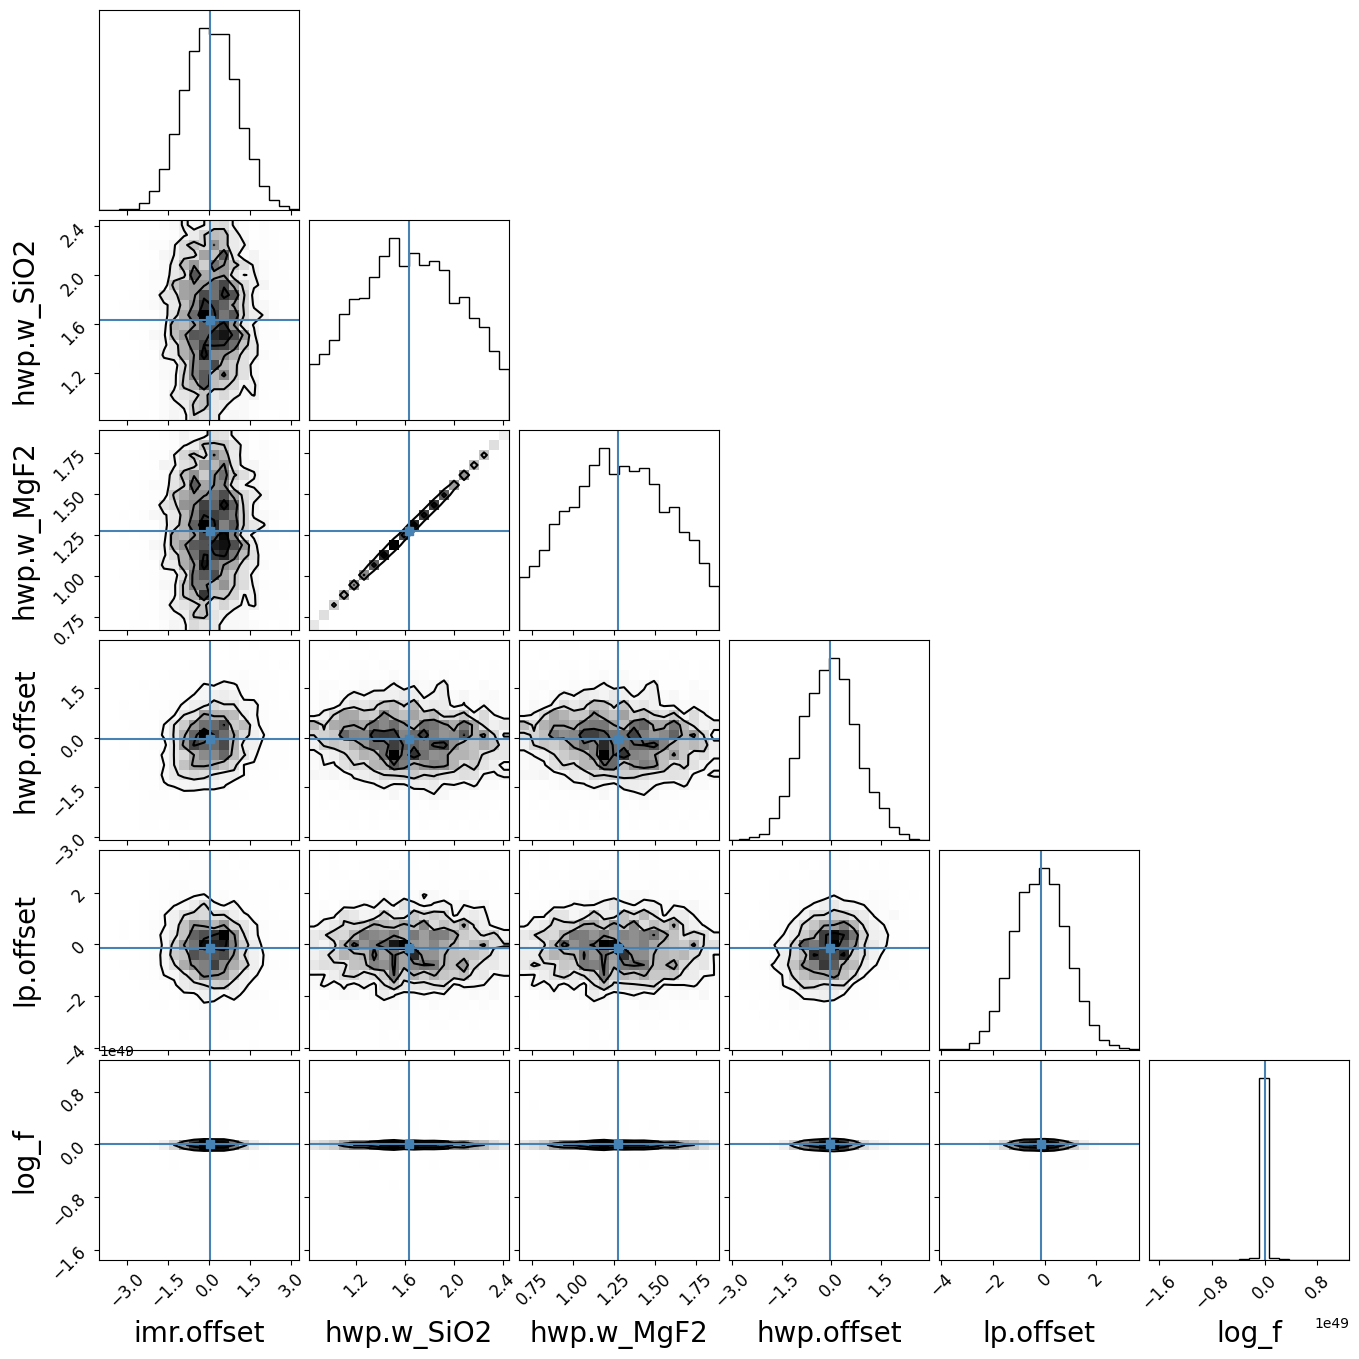

In [7]:
# First you need to get the chains and labels, then you can create a corner plot
from pyPolCal.plotting import plot_corner_flat, load_chain_and_labels
chain, names = load_chain_and_labels('mcmc_tutorial_output.h5', 'mcmc_p0.json', include_logf=True)
fig, ax = plot_corner_flat(chain, names, step_range=(2000,3000))

# Step 5: Check Polarimetric Accuracy
This way you can see if this fit is any better than minimize.

In [8]:
system_dict_fitted = {
    "components" : {
        "wollaston" : {
        "type" : "fitted_wollaston_function_12_28_2025",
        "properties" : {"beam": 'o'}, 
        "tag": "internal",
        },

        "nbs_rot": {
            "type": "rotator_function",
            "properties": {"pa": 90},
            "tag": "internal",
        },
        "image_rotator" : {
        "type" : "fitted_derotator_function_12_28_2025",
        "properties" : {"delta_theta":0.05}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"w_SiO2": 1.63258, "w_MgF2":1.277, "delta_theta": -0.04},
            "tag": "internal",
        },


        "lp" :{
            "type" : "diattenuator_retarder_function",
            "properties" : {"epsilon": -1, "delta_theta":-0.15}, 
            "tag": "internal",
        },
}
}

p0_dict_forsrel = {
    "hwp": {"delta_theta":-0.005}
}


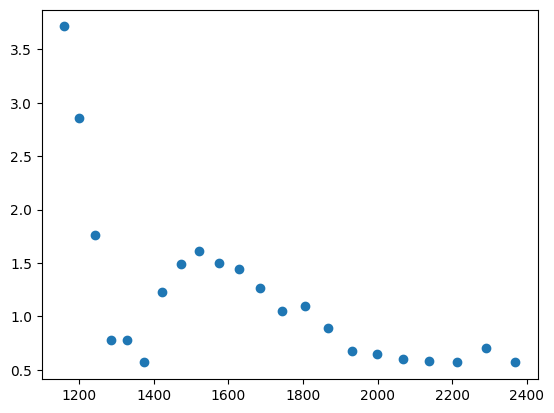

In [9]:
from pyPolCal.fitting import calc_s_res_global
from pyPolCal.constants import wavelength_bins
import matplotlib.pyplot as plt

r_rel = calc_s_res_global(csvdir, system_dict_fitted,p0_dict_forsrel,number_of_fitted_params=4)
plt.scatter(wavelength_bins, r_rel)

MCMC actually performed slightly worse than minimize for my dataset. You can also use MCMC for on sky data if you'd like. It's the exact same process, just use the instructions for writing a CSV with on sky data in the next tutorial notebook.